In [1]:
import pandas as pd
import seaborn as sns
from IPython.display import display as d
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
import starbars
import scipy.stats as stats

In [2]:
dai = pd.read_csv("ai_images.csv")
dai

,user_id,pid,preferred
0,1,p35,org
1,1,p41,lark
2,1,p26,perpetua
3,1,p33,aden
4,1,p10,valencia
...,...,...,...
1129,21,p46,toaster
1130,21,p02,willow
1131,21,p32,nashville
1132,21,p51,valencia


In [3]:
dreal = pd.read_csv("real_images.csv")
dreal

,user_id,pid,preferred
0,1,p07,aden
1,1,p40,clarendon
2,1,p54,kelvin
3,1,p18,lark
4,1,p32,lofi
...,...,...,...
1129,21,p06,gingham
1130,21,p46,gingham
1131,21,p05,stinson
1132,21,p24,org


In [4]:
dai[dai["pid"] == "p01"]

,user_id,pid,preferred
6,1,p01,org
63,2,p01,maven
125,3,p01,clarendon
191,4,p01,clarendon
228,5,p01,lark
306,6,p01,clarendon
347,7,p01,valencia
390,8,p01,earlybird
445,9,p01,perpetua
521,10,p01,nashville


In [5]:
dai[dai["pid"] == "p20"]

,user_id,pid,preferred
26,1,p20,aden
97,2,p20,kelvin
160,3,p20,kelvin
171,4,p20,lofi
220,5,p20,brannan
289,6,p20,brannan
333,7,p20,kelvin
428,8,p20,gingham
435,9,p20,brooklyn
509,10,p20,toaster


In [6]:
dreal[dreal["pid"] == "p20"]

,user_id,pid,preferred
13,1,p20,clarendon
63,2,p20,perpetua
141,3,p20,rise
207,4,p20,lofi
248,5,p20,aden
277,6,p20,nashville
327,7,p20,lark
429,8,p20,brooklyn
469,9,p20,clarendon
493,10,p20,lofi


In [7]:
dai["type"] = "ai"
dreal["type"] = "real"

dall = pd.concat([dai, dreal], ignore_index=True)
dall["org"] = dall["preferred"].apply(lambda x: x == "org")
dall

,user_id,pid,preferred,type,org
0,1,p35,org,ai,True
1,1,p41,lark,ai,False
2,1,p26,perpetua,ai,False
3,1,p33,aden,ai,False
4,1,p10,valencia,ai,False
...,...,...,...,...,...
2263,21,p06,gingham,real,False
2264,21,p46,gingham,real,False
2265,21,p05,stinson,real,False
2266,21,p24,org,real,True


<Axes: xlabel='org', ylabel='count'>

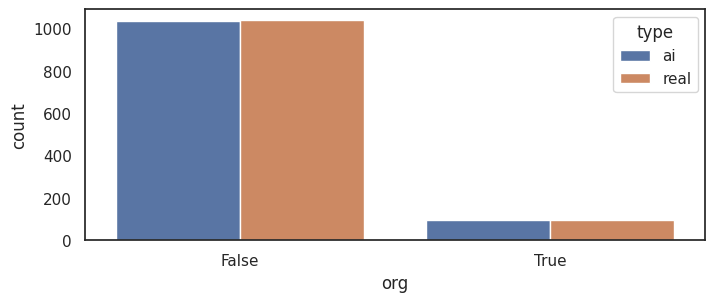

In [8]:
# org vs not org
sns.set(rc={'figure.figsize':(8,3)})
sns.set_style("white")
sns.countplot(x="org", hue="type", data=dall)

<Axes: xlabel='count', ylabel='pid'>

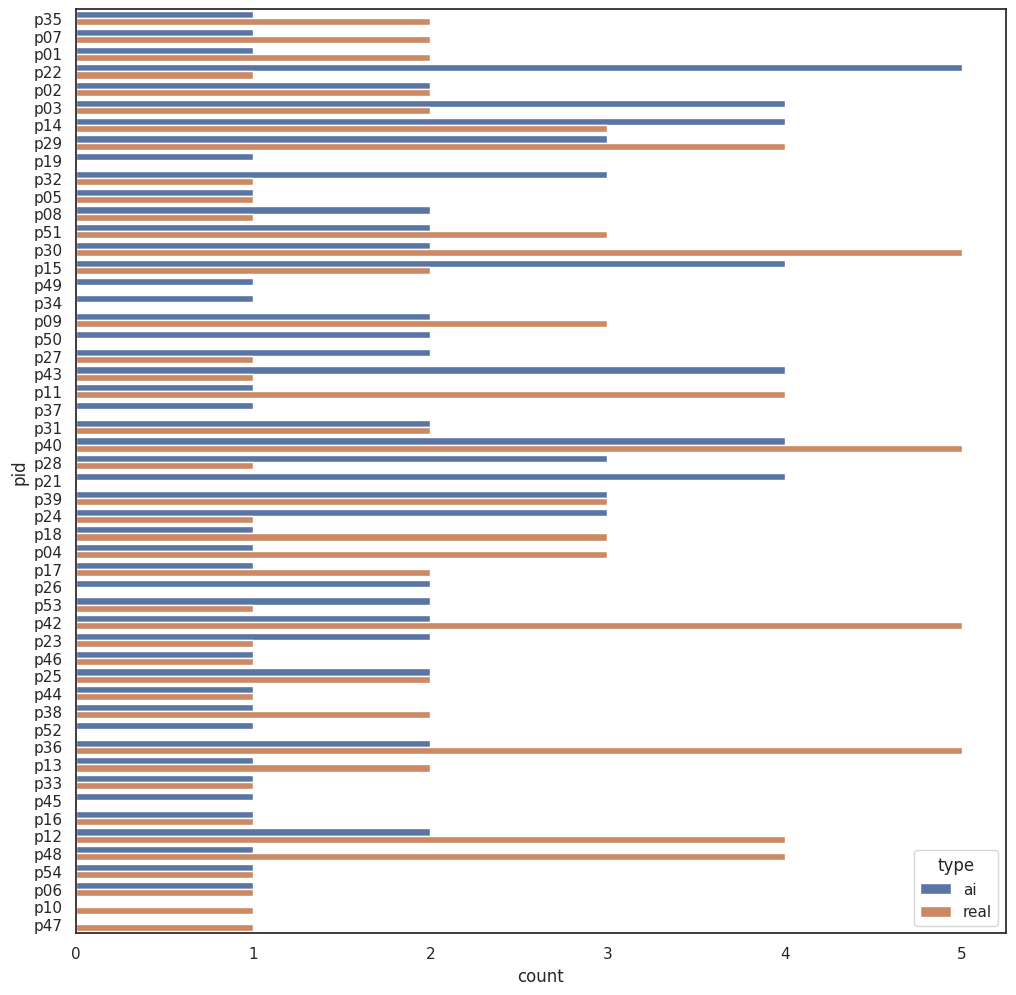

In [9]:
sns.set(rc={'figure.figsize':(12,12)})
sns.set_style("white")
sns.countplot(y="pid", hue="type", data=dall[dall["org"]])

In [10]:
dpercentage = dall.groupby(by=["type", "pid"]).apply(
    lambda x: 
        pd.Series({"%": 100 * x["org"].sum() / len(x["org"])}), 
    include_groups=False
).reset_index()
dpercentage

,type,pid,%
0,ai,p01,4.761905
1,ai,p02,9.523810
2,ai,p03,19.047619
3,ai,p04,4.761905
4,ai,p05,4.761905
...,...,...,...
103,real,p50,0.000000
104,real,p51,14.285714
105,real,p52,0.000000
106,real,p53,4.761905


Text(0, 0.5, '% of ratings where original images are preferred over filtered')

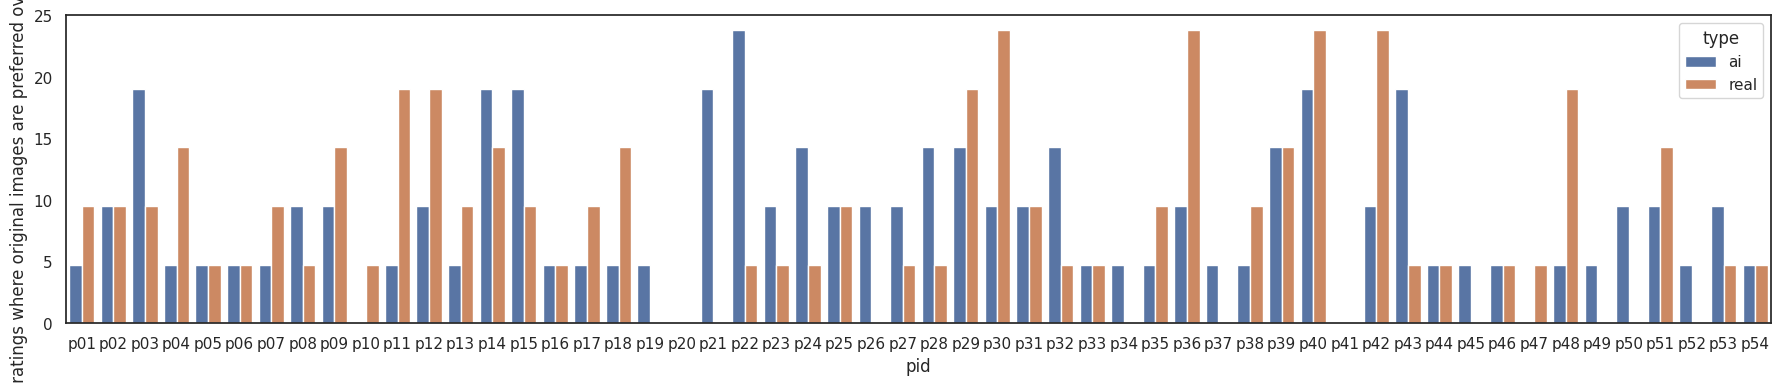

In [11]:
sns.set(rc={'figure.figsize':(22,4)})
sns.set_style("white")
ax = sns.barplot(y="%", x="pid", hue="type" , data=dpercentage)
ax.set_ylabel("% of ratings where original images are preferred over filtered")

In [12]:


#sns.heatmap()
dt = dpercentage[dpercentage["type"]== "ai"][["pid","%"]].transpose()
dt.columns = dt.iloc[0]
dt = dt.drop(dt.index[0])
dt = dt[[x for x in dt.columns if not "pid" in x]]
dt

pid,p01,p02,p03,p04,p05,p06,p07,p08,p09,p10,...,p45,p46,p47,p48,p49,p50,p51,p52,p53,p54
%,4.761905,9.52381,19.047619,4.761905,4.761905,4.761905,4.761905,9.52381,9.52381,0.0,...,4.761905,4.761905,0.0,4.761905,4.761905,9.52381,9.52381,4.761905,9.52381,4.761905


<Axes: xlabel='pid'>

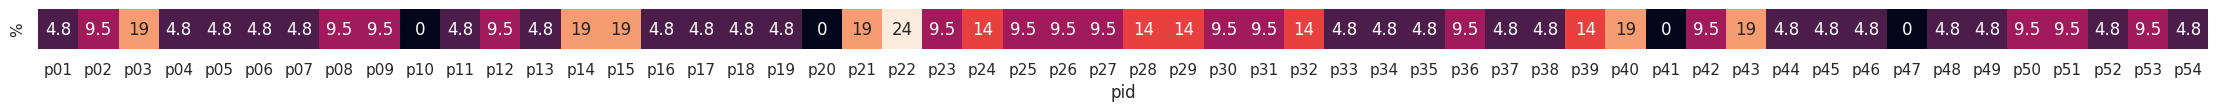

In [13]:
sns.set(rc={'figure.figsize':(28,2)})
sns.set_style("white")

sns.heatmap(
    dt.astype(float),
    annot=True, square=True, cbar=False
)

In [14]:
dpercentage[dpercentage["%"] == 0.0]

,type,pid,%
9,ai,p10,0.0
19,ai,p20,0.0
40,ai,p41,0.0
46,ai,p47,0.0
72,real,p19,0.0
73,real,p20,0.0
74,real,p21,0.0
79,real,p26,0.0
87,real,p34,0.0
90,real,p37,0.0


<Axes: xlabel='count', ylabel='preferred'>

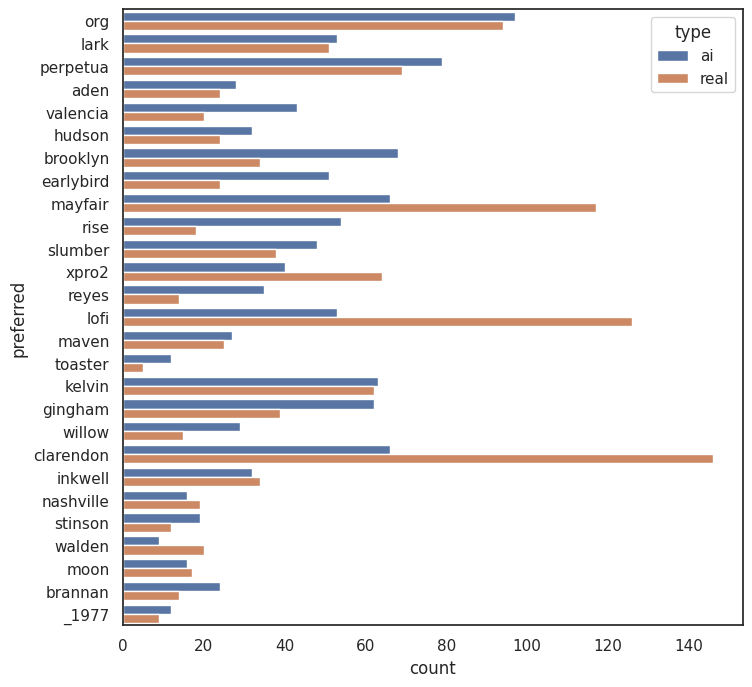

In [15]:
# preferred filter
sns.set(rc={'figure.figsize':(8,8)})
sns.set_style("white")

# make it in %...
sns.countplot(y="preferred", hue="type", data=dall)

In [16]:
dall.groupby(by=["type", "pid", "preferred"]).sum()

user_id  org
type pid preferred              
ai   p01 brannan         14    0
         brooklyn        11    0
         clarendon       13    0
         earlybird        8    0
         inkwell         21    0
...                     ...  ...
real p54 reyes           12    0
         rise            10    0
         slumber         20    0
         willow          16    0
         xpro2            9    0

[1311 rows x 2 columns]

In [17]:
dall[dall["pid"] == "p01"][dall["type"] == "ai"]

/tmp/ipykernel_1593125/2960509472.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dall[dall["pid"] == "p01"][dall["type"] == "ai"]


,user_id,pid,preferred,type,org
6,1,p01,org,ai,True
63,2,p01,maven,ai,False
125,3,p01,clarendon,ai,False
191,4,p01,clarendon,ai,False
228,5,p01,lark,ai,False
306,6,p01,clarendon,ai,False
347,7,p01,valencia,ai,False
390,8,p01,earlybird,ai,False
445,9,p01,perpetua,ai,False
521,10,p01,nashville,ai,False


In [18]:
dcounts = dall.groupby(by=["type", "pid"]).apply(
    lambda x: 
        pd.Series({"count": len(x) }), 
    include_groups=False
).reset_index()

dcounts

,type,pid,count
0,ai,p01,21
1,ai,p02,21
2,ai,p03,21
3,ai,p04,21
4,ai,p05,21
...,...,...,...
103,real,p50,21
104,real,p51,21
105,real,p52,21
106,real,p53,21


In [19]:
df = dall.groupby(by=["type", "pid", "preferred"]).apply(
    lambda x: 
        pd.Series({"filter_count": len(x) }), 
    include_groups=False
).reset_index()

df = pd.merge(df, dcounts, left_on=["type", "pid"], right_on=["type", "pid"])
df["filter_%"] = df["filter_count"] / df["count"]
df[df["pid"] == "p01"]

,type,pid,preferred,filter_count,count,filter_%
0,ai,p01,brannan,1,21,0.047619
1,ai,p01,brooklyn,1,21,0.047619
2,ai,p01,clarendon,3,21,0.142857
3,ai,p01,earlybird,1,21,0.047619
4,ai,p01,inkwell,1,21,0.047619
5,ai,p01,lark,1,21,0.047619
6,ai,p01,maven,1,21,0.047619
7,ai,p01,mayfair,5,21,0.238095
8,ai,p01,nashville,1,21,0.047619
9,ai,p01,org,1,21,0.047619


In [20]:
# convert to short format?

df_ai = df[df["type"] == "ai"].copy()[["pid", "preferred", "filter_%"]]
df_ai

,pid,preferred,filter_%
0,p01,brannan,0.047619
1,p01,brooklyn,0.047619
2,p01,clarendon,0.142857
3,p01,earlybird,0.047619
4,p01,inkwell,0.047619
...,...,...,...
697,p54,rise,0.047619
698,p54,slumber,0.047619
699,p54,stinson,0.095238
700,p54,willow,0.047619


In [21]:
df_ai_pivot = df_ai.pivot(index="pid", columns="preferred", values="filter_%").fillna(0)


<Axes: xlabel='preferred', ylabel='pid'>

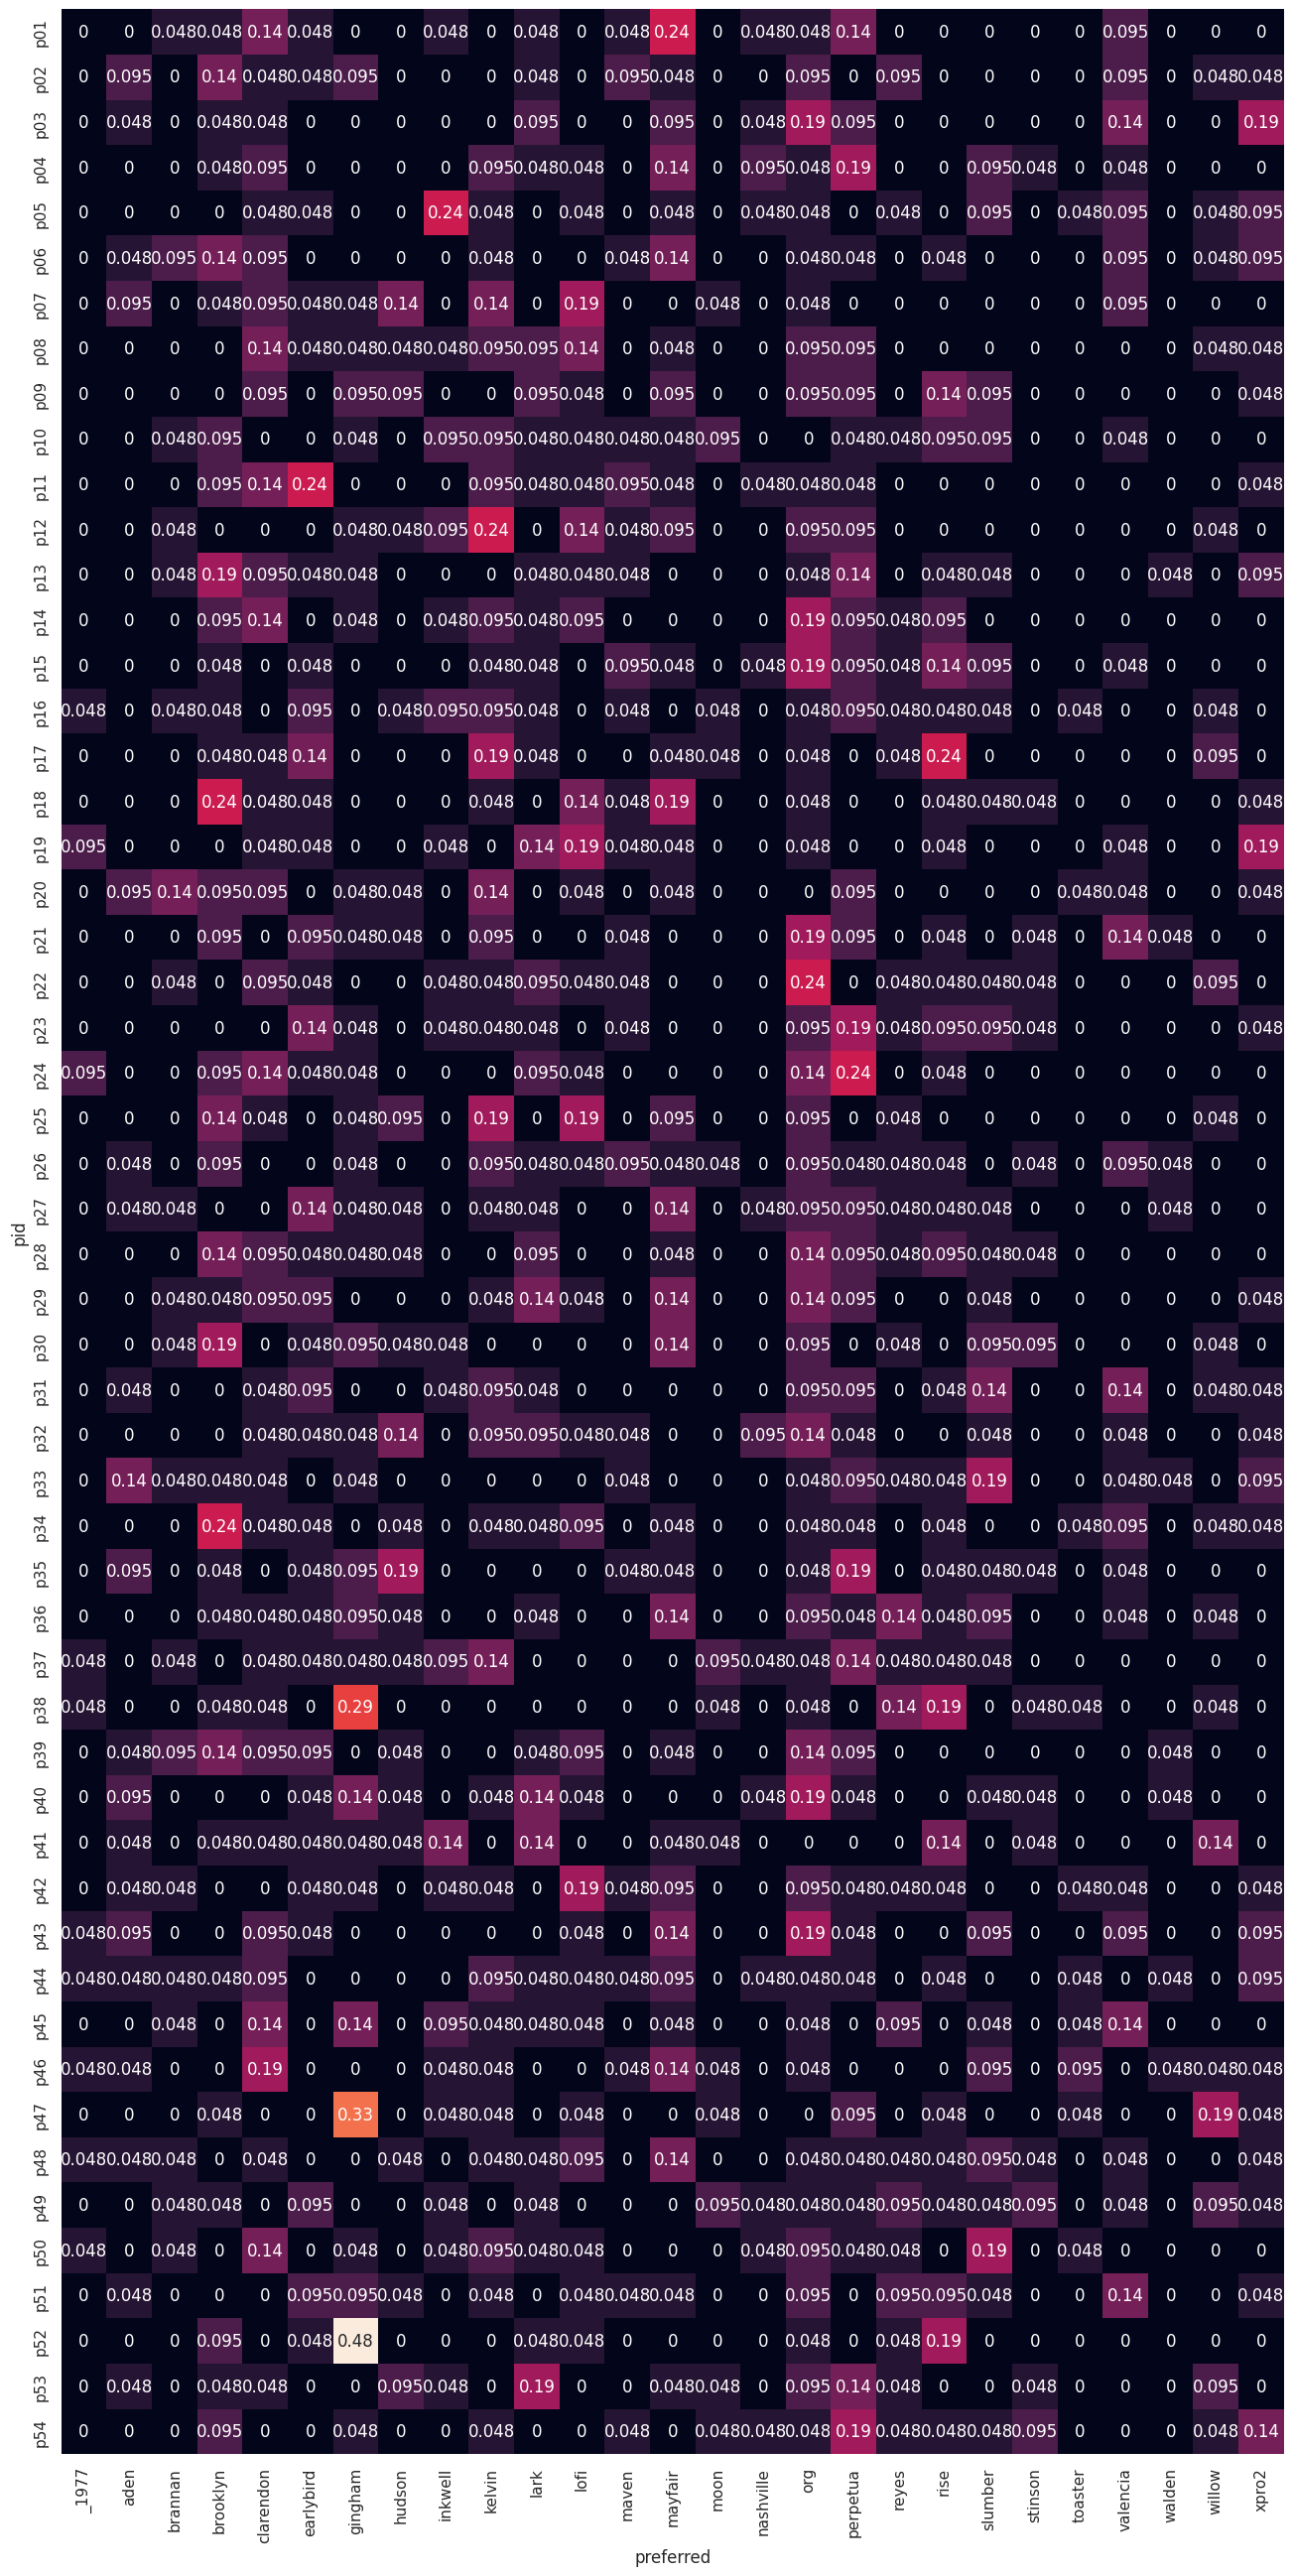

In [22]:
sns.set(rc={'figure.figsize':(32,32)})
sns.set_style("white")

sns.heatmap(
    df_ai_pivot.astype(float),
    annot=True, square=True, cbar=False
)

In [23]:
df = dall.groupby(by=["type", "preferred"]).apply(
    lambda x: 
        pd.Series({"filter_count": len(x) }), 
    include_groups=False
).reset_index()
df

,type,preferred,filter_count
0,ai,_1977,12
1,ai,aden,28
2,ai,brannan,24
3,ai,brooklyn,68
4,ai,clarendon,66
5,ai,earlybird,51
6,ai,gingham,62
7,ai,hudson,32
8,ai,inkwell,32
9,ai,kelvin,63


In [24]:
df_ai_pivot = df.pivot(index="type", columns="preferred", values="filter_count").fillna(0)
df_ai_pivot

preferred,_1977,aden,brannan,brooklyn,clarendon,earlybird,gingham,hudson,inkwell,kelvin,...,perpetua,reyes,rise,slumber,stinson,toaster,valencia,walden,willow,xpro2
type,,,,,,,,,,,,,,,,,,,,,
ai,12,28,24,68,66,51,62,32,32,63,...,79,35,54,48,19,12,43,9,29,40
real,9,24,14,34,146,24,39,24,34,62,...,69,14,18,38,12,5,20,20,15,64


<Axes: xlabel='preferred', ylabel='type'>

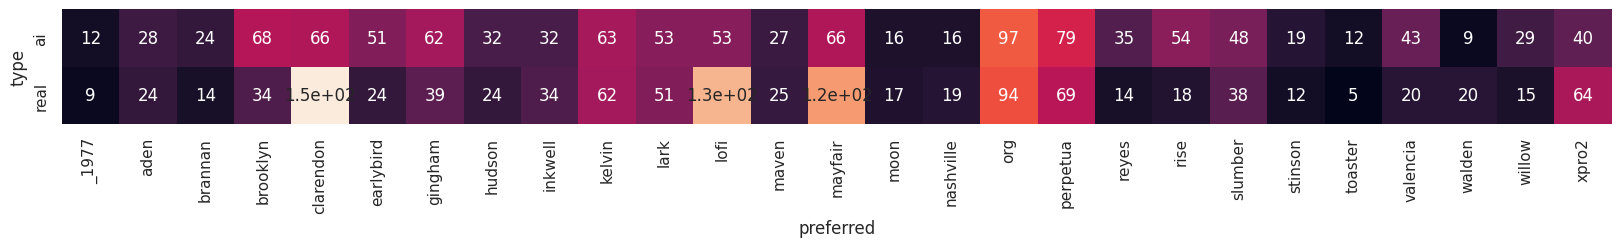

In [25]:
sns.set(rc={'figure.figsize':(20,32)})
sns.set_style("white")

sns.heatmap(
    df_ai_pivot.astype(float),
    annot=True, square=True, cbar=False
)

In [26]:
dall


,user_id,pid,preferred,type,org
0,1,p35,org,ai,True
1,1,p41,lark,ai,False
2,1,p26,perpetua,ai,False
3,1,p33,aden,ai,False
4,1,p10,valencia,ai,False
...,...,...,...,...,...
2263,21,p06,gingham,real,False
2264,21,p46,gingham,real,False
2265,21,p05,stinson,real,False
2266,21,p24,org,real,True


<Axes: xlabel='percent', ylabel='preferred'>

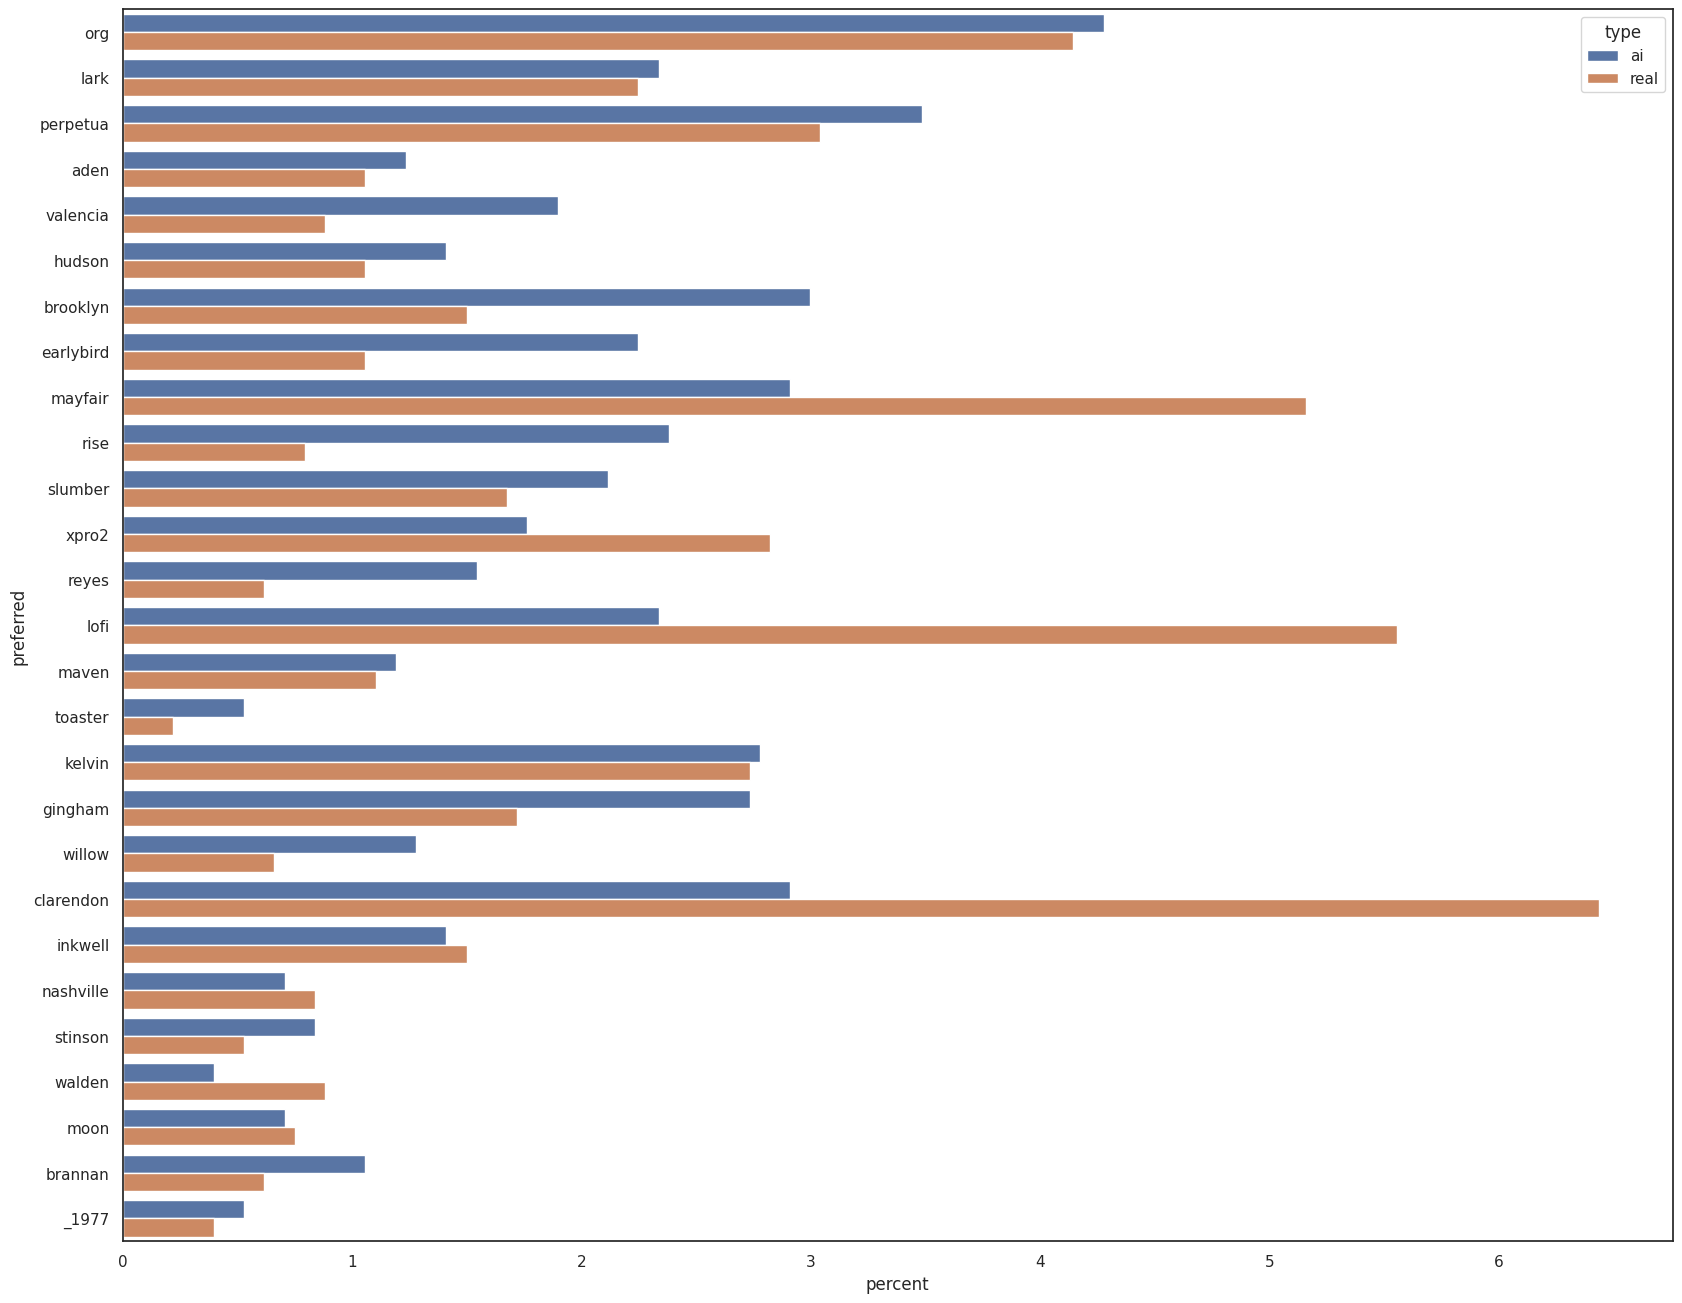

In [27]:
sns.set(rc={'figure.figsize':(20,16)})
sns.set_style("white")

sns.countplot(y="preferred", hue="type", data=dall, stat="percent")

In [28]:
dt = dall[dall["type"] == "ai"]
dt

,user_id,pid,preferred,type,org
0,1,p35,org,ai,True
1,1,p41,lark,ai,False
2,1,p26,perpetua,ai,False
3,1,p33,aden,ai,False
4,1,p10,valencia,ai,False
...,...,...,...,...,...
1129,21,p46,toaster,ai,False
1130,21,p02,willow,ai,False
1131,21,p32,nashville,ai,False
1132,21,p51,valencia,ai,False


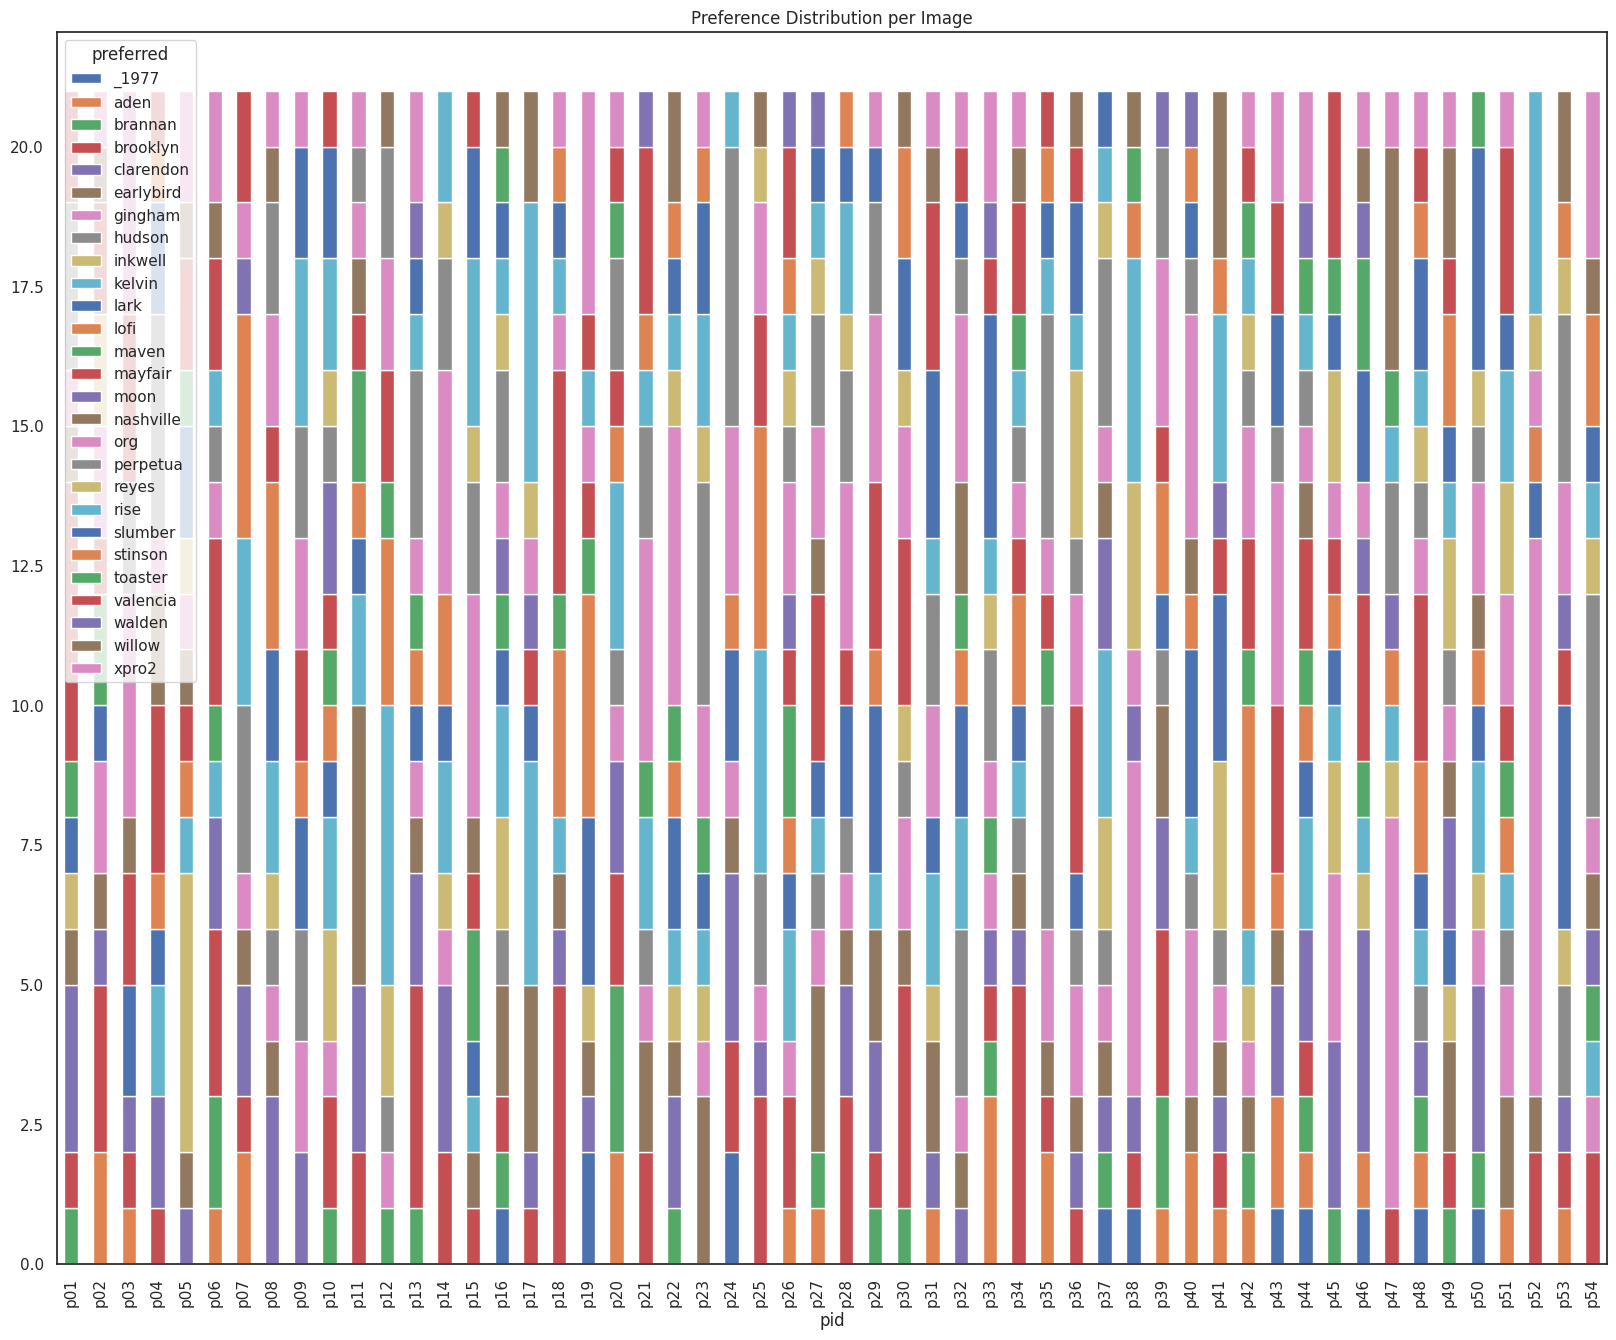

In [29]:
import matplotlib.pyplot as plt

img_variant_counts = dt.groupby(["pid", "preferred"]).size().unstack()
img_variant_counts.plot(kind="bar", stacked=True)
plt.title("Preference Distribution per Image")
plt.show()

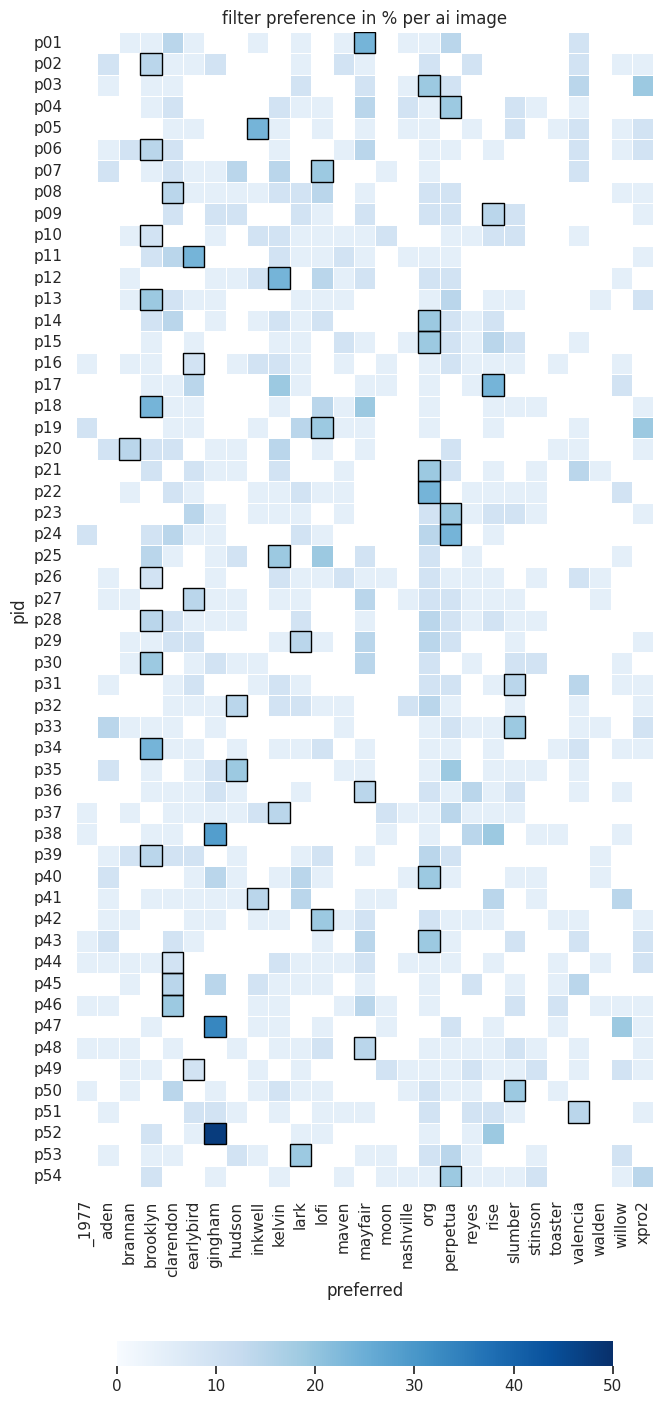

p52 gingham


In [36]:
sns.set(rc={'figure.figsize':(8,32)})
sns.set_style("white")
import matplotlib.patches as patches

dt = dall[dall["type"] == "ai"]
counts = dt.groupby(["pid", "preferred"]).size().unstack()

percent_data = counts.div(counts.sum(axis=1), axis=0) * 100 

# Highlight the winning variant per image
plt.figure(figsize=(16, 20))
ax = sns.heatmap(percent_data, annot=False, cbar=True, cmap="Blues", fmt="0.0f", square=True, linewidths=0.5,
    vmin=0, vmax=50,
    cbar_kws={"orientation": "horizontal", "location": "bottom", 'shrink': 0.4, "pad": 0.1}
)
plt.title("filter preference in % per ai image")

#print(percent_data)
for i in range(len(percent_data)):
    max_col = percent_data.iloc[i].idxmax()
    j = list(percent_data.columns).index(max_col)  # Get column index
    
    rect = patches.Rectangle(
        (j, i), 1, 1,
        linewidth=1, edgecolor='black', facecolor='none'
    )
    ax.add_patch(rect)

plt.show()

ax.get_figure().savefig("hm_ai_images_filters.pdf", bbox_inches="tight")

print(
    percent_data.idxmax()[percent_data.max().idxmax()], percent_data.max().idxmax()
    
)
      

In [37]:
# most often selected filter per text prompt
best_filter_per_prompt_ai = pd.DataFrame({"ai": percent_data.idxmax(axis=1) }).reset_index()
best_filter_per_prompt_ai

,pid,ai
0,p01,mayfair
1,p02,brooklyn
2,p03,org
3,p04,perpetua
4,p05,inkwell
5,p06,brooklyn
6,p07,lofi
7,p08,clarendon
8,p09,rise
9,p10,brooklyn


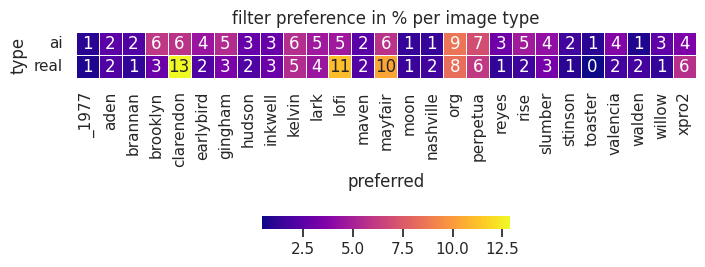

In [38]:
dt = dall.copy()

counts = dt.groupby(["type", "preferred"]).size().unstack()
percent_data = counts.div(counts.sum(axis=1), axis=0) * 100 


plt.figure(figsize=(8, 24))
ax = sns.heatmap(percent_data, annot=True, cbar=True, cmap="plasma", fmt="0.0f", square=True, linewidths=0.5,
    #vmin=0, vmax=100,
    cbar_kws={"orientation": "horizontal", "location": "bottom", 'shrink': 0.4, "pad": 0.075}
)
plt.yticks(rotation=0) 
plt.title("filter preference in % per image type")
plt.show()
ax.get_figure().savefig("hm_real_vs_ai.pdf", bbox_inches="tight")

In [39]:
# top filter ranking per type
top = percent_data.transpose().reset_index()

top_ai = top.sort_values(by="ai", ascending=False).head(5).copy()[["preferred", "ai"]].round(0)
d(top_ai)

top_real = top.sort_values(by="real", ascending=False).head(5).copy()[["preferred", "real"]].round(0)

d(top_real)

print(top_ai.to_latex(float_format=lambda x: '%.0f' % x, index=False))
print(top_real.to_latex(float_format=lambda x: '%.0f' % x, index=False))

type,preferred,ai
16,org,9.0
17,perpetua,7.0
3,brooklyn,6.0
13,mayfair,6.0
4,clarendon,6.0


type,preferred,real
4,clarendon,13.0
11,lofi,11.0
13,mayfair,10.0
16,org,8.0
17,perpetua,6.0


\begin{tabular}{lr}
\toprule
preferred & ai \\
\midrule
org & 9 \\
perpetua & 7 \\
brooklyn & 6 \\
mayfair & 6 \\
clarendon & 6 \\
\bottomrule
\end{tabular}

\begin{tabular}{lr}
\toprule
preferred & real \\
\midrule
clarendon & 13 \\
lofi & 11 \\
mayfair & 10 \\
org & 8 \\
perpetua & 6 \\
\bottomrule
\end{tabular}



In [40]:
# tail 3 filter ranking per type
tail = percent_data.transpose().reset_index()

tail_ai = tail.sort_values(by="ai", ascending=False).tail(5).copy()[["preferred", "ai"]].round(0)
d(tail_ai)

tail_real = tail.sort_values(by="real", ascending=False).tail(5).copy()[["preferred", "real"]].round(0)

d(tail_real)

print(tail_ai.to_latex(float_format=lambda x: '%.0f' % x, index=False))
print(tail_real.to_latex(float_format=lambda x: '%.0f' % x, index=False))

type,preferred,ai
14,moon,1.0
15,nashville,1.0
22,toaster,1.0
0,_1977,1.0
24,walden,1.0


type,preferred,real
2,brannan,1.0
18,reyes,1.0
21,stinson,1.0
0,_1977,1.0
22,toaster,0.0


\begin{tabular}{lr}
\toprule
preferred & ai \\
\midrule
moon & 1 \\
nashville & 1 \\
toaster & 1 \\
_1977 & 1 \\
walden & 1 \\
\bottomrule
\end{tabular}

\begin{tabular}{lr}
\toprule
preferred & real \\
\midrule
brannan & 1 \\
reyes & 1 \\
stinson & 1 \\
_1977 & 1 \\
toaster & 0 \\
\bottomrule
\end{tabular}



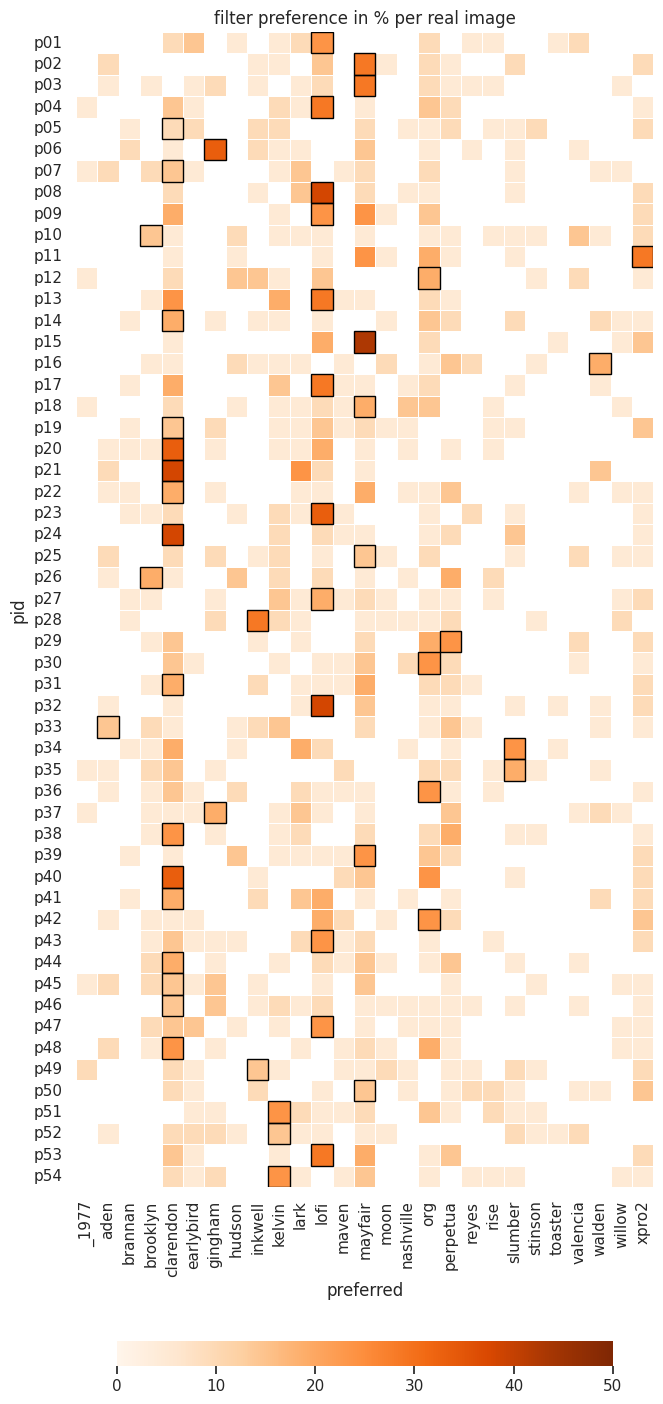

p15 mayfair


In [41]:
sns.set(rc={'figure.figsize':(8,32)})
sns.set_style("white")

dt = dall[dall["type"] == "real"]
counts = dt.groupby(["pid", "preferred"]).size().unstack()

percent_data = counts.div(counts.sum(axis=1), axis=0) * 100 

# Highlight the winning variant per image
plt.figure(figsize=(16, 20))
ax = sns.heatmap(percent_data, annot=False, cbar=True, cmap="Oranges", fmt="0.0f", square=True, linewidths=0.5,
    vmin=0, vmax=50,
    cbar_kws={"orientation": "horizontal", "location": "bottom", 'shrink': 0.4, "pad": 0.1}
)
for i in range(len(percent_data)):
    max_col = percent_data.iloc[i].idxmax()
    j = list(percent_data.columns).index(max_col)  # Get column index
    
    rect = patches.Rectangle(
        (j, i), 1, 1,
        linewidth=1, edgecolor='black', facecolor='none'
    )
    ax.add_patch(rect)
    
plt.title("filter preference in % per real image")
plt.show()
ax.get_figure().savefig("hm_real_images_filters.pdf", bbox_inches="tight")

print(
    percent_data.idxmax()[percent_data.max().idxmax()], percent_data.max().idxmax()
    
)

In [42]:
best_filter_per_prompt_real = pd.DataFrame({"real": percent_data.idxmax(axis=1) }).reset_index()
best_filter_per_prompt_real

,pid,real
0,p01,lofi
1,p02,mayfair
2,p03,mayfair
3,p04,lofi
4,p05,clarendon
5,p06,gingham
6,p07,clarendon
7,p08,lofi
8,p09,lofi
9,p10,brooklyn


In [43]:
best_filter_per_prompt = pd.merge(best_filter_per_prompt_ai, best_filter_per_prompt_real)
best_filter_per_prompt

,pid,ai,real
0,p01,mayfair,lofi
1,p02,brooklyn,mayfair
2,p03,org,mayfair
3,p04,perpetua,lofi
4,p05,inkwell,clarendon
5,p06,brooklyn,gingham
6,p07,lofi,clarendon
7,p08,clarendon,lofi
8,p09,rise,lofi
9,p10,brooklyn,brooklyn


In [44]:
print(
    best_filter_per_prompt.to_latex(index=False)
)

# TODO: check "appeal" score before and after filtering

\begin{tabular}{lll}
\toprule
pid & ai & real \\
\midrule
p01 & mayfair & lofi \\
p02 & brooklyn & mayfair \\
p03 & org & mayfair \\
p04 & perpetua & lofi \\
p05 & inkwell & clarendon \\
p06 & brooklyn & gingham \\
p07 & lofi & clarendon \\
p08 & clarendon & lofi \\
p09 & rise & lofi \\
p10 & brooklyn & brooklyn \\
p11 & earlybird & xpro2 \\
p12 & kelvin & org \\
p13 & brooklyn & lofi \\
p14 & org & clarendon \\
p15 & org & mayfair \\
p16 & earlybird & walden \\
p17 & rise & lofi \\
p18 & brooklyn & mayfair \\
p19 & lofi & clarendon \\
p20 & brannan & clarendon \\
p21 & org & clarendon \\
p22 & org & clarendon \\
p23 & perpetua & lofi \\
p24 & perpetua & clarendon \\
p25 & kelvin & mayfair \\
p26 & brooklyn & brooklyn \\
p27 & earlybird & lofi \\
p28 & brooklyn & inkwell \\
p29 & lark & perpetua \\
p30 & brooklyn & org \\
p31 & slumber & clarendon \\
p32 & hudson & lofi \\
p33 & slumber & aden \\
p34 & brooklyn & slumber \\
p35 & hudson & slumber \\
p36 & mayfair & org \\
p37 & kelvin 

In [45]:
# Calculate agreement metrics per image
def compute_agreement(group):
    variant_counts = group["preferred"].value_counts(normalize=True)
    return {
        "entropy": entropy(variant_counts),  # Higher entropy = more disagreement
        "majority_%": variant_counts.max(),  # % of users choosing the top variant (Majority Preference % (higher = more agreement))
        "number_of_filters": len(variant_counts)
    }

agreement = dall.groupby(by=["type", "pid"]).apply(compute_agreement).apply(pd.Series).reset_index()

agreement

/tmp/ipykernel_1593125/2986979447.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agreement = dall.groupby(by=["type", "pid"]).apply(compute_agreement).apply(pd.Series).reset_index()


,type,pid,entropy,majority_%,number_of_filters
0,ai,p01,2.281420,0.238095,12.0
1,ai,p02,2.491494,0.142857,13.0
2,ai,p03,2.161424,0.190476,10.0
3,ai,p04,2.359466,0.190476,12.0
4,ai,p05,2.463281,0.238095,14.0
...,...,...,...,...,...
103,real,p50,2.466577,0.142857,13.0
104,real,p51,2.306336,0.238095,12.0
105,real,p52,2.557508,0.142857,14.0
106,real,p53,1.888632,0.285714,8.0


In [46]:
agreement[["type", "entropy", "majority_%", "number_of_filters"]].groupby(by="type").mean().reset_index()

,type,entropy,majority_%,number_of_filters
0,ai,2.414684,0.184303,13.000000
1,real,2.218519,0.235450,11.277778


1.5900499855001178e-05
-2.0 0.03


,type,pid,entropy,majority_%,number_of_filters
74,real,p21,1.580182,0.380952,6.0
68,real,p15,1.615840,0.428571,7.0
51,ai,p52,1.617983,0.476190,8.0
93,real,p40,1.723714,0.333333,7.0
62,real,p09,1.791109,0.238095,7.0
...,...,...,...,...,...
25,ai,p26,2.714452,0.095238,16.0
48,ai,p49,2.714452,0.095238,16.0
47,ai,p48,2.755550,0.142857,17.0
15,ai,p16,2.780466,0.095238,17.0


,type,pid,entropy,majority_%,number_of_filters
43,ai,p44,2.780466,0.095238,17.0
15,ai,p16,2.780466,0.095238,17.0
47,ai,p48,2.755550,0.142857,17.0
48,ai,p49,2.714452,0.095238,16.0
25,ai,p26,2.714452,0.095238,16.0
41,ai,p42,2.648438,0.190476,16.0
9,ai,p10,2.648438,0.095238,15.0
36,ai,p37,2.598605,0.142857,15.0
26,ai,p27,2.598605,0.142857,15.0
99,real,p46,2.598605,0.142857,15.0


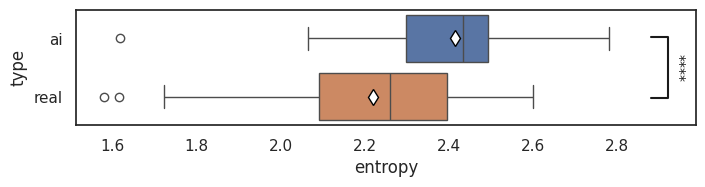

In [502]:
sns.set(rc={'figure.figsize':(8,1.5)})
sns.set_style("white")

ax = sns.boxplot(x="entropy",y="type", hue="type", data=agreement, showmeans=True, meanprops={'marker':'d','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'})


t_stat, p_value = stats.ttest_ind(agreement[agreement["type"] == "ai"]["entropy"], agreement[agreement["type"] == "real"]["entropy"])

print(p_value)
annotations = [("real", "ai", p_value)]
starbars.draw_annotation(annotations, mode="horizontal")
ax.get_figure().savefig("entropy.pdf", bbox_inches="tight")

d(agreement.sort_values(by=["entropy"]))
d(agreement.sort_values(by=["entropy"], ascending=False).head(20))

0.0002584567152186854
-2.0 0.03


,type,pid,entropy,majority_%,number_of_filters
51,ai,p52,1.617983,0.476190,8.0
68,real,p15,1.615840,0.428571,7.0
77,real,p24,1.897368,0.380952,9.0
74,real,p21,1.580182,0.380952,6.0
85,real,p32,2.029396,0.380952,11.0
...,...,...,...,...,...
15,ai,p16,2.780466,0.095238,17.0
58,real,p05,2.516410,0.095238,13.0
9,ai,p10,2.648438,0.095238,15.0
43,ai,p44,2.780466,0.095238,17.0


,type,pid,entropy,majority_%,number_of_filters
15,ai,p16,2.780466,0.095238,17.0
43,ai,p44,2.780466,0.095238,17.0
48,ai,p49,2.714452,0.095238,16.0
58,real,p05,2.516410,0.095238,13.0
25,ai,p26,2.714452,0.095238,16.0
...,...,...,...,...,...
61,real,p08,1.897368,0.380952,9.0
85,real,p32,2.029396,0.380952,11.0
77,real,p24,1.897368,0.380952,9.0
68,real,p15,1.615840,0.428571,7.0


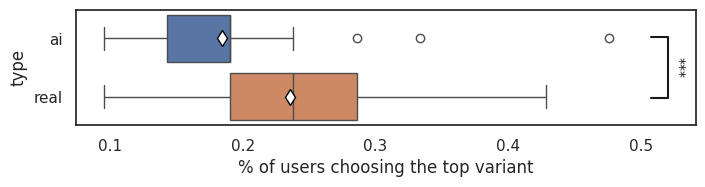

In [503]:
sns.set(rc={'figure.figsize':(8,1.5)})
sns.set_style("white")

ax = sns.boxplot(x="majority_%", y="type", hue="type", data=agreement, showmeans=True, meanprops={'marker':'d','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'})
ax.set_xlabel("% of users choosing the top variant")
t_stat, p_value = stats.ttest_ind(agreement[agreement["type"] == "ai"]["majority_%"], agreement[agreement["type"] == "real"]["majority_%"])

print(p_value)
annotations = [("real", "ai", p_value)]
starbars.draw_annotation(annotations, mode="horizontal")
ax.get_figure().savefig("majority.pdf", bbox_inches="tight")
"""

Symbol : Meaning

ns : P > 0.05
* : P ≤ 0.05
** : P ≤ 0.01
*** : P ≤ 0.001
**** :  P ≤ 0.0001 (For the last two choices only)
"""
d(agreement.sort_values(by=["majority_%"], ascending=False))
d(agreement.sort_values(by=["majority_%"], ascending=True))

2.0497753900790093e-05
-2.0 0.03


,type,pid,entropy,majority_%,number_of_filters
74,real,p21,1.580182,0.380952,6.0
62,real,p09,1.791109,0.238095,7.0
68,real,p15,1.615840,0.428571,7.0
93,real,p40,1.723714,0.333333,7.0
66,real,p13,1.819322,0.285714,8.0
51,ai,p52,1.617983,0.476190,8.0
106,real,p53,1.888632,0.285714,8.0
82,real,p29,2.042280,0.238095,9.0
61,real,p08,1.897368,0.380952,9.0
64,real,p11,1.885336,0.285714,9.0


,type,pid,entropy,majority_%,number_of_filters
15,ai,p16,2.780466,0.095238,17.0
47,ai,p48,2.755550,0.142857,17.0
43,ai,p44,2.780466,0.095238,17.0
48,ai,p49,2.714452,0.095238,16.0
25,ai,p26,2.714452,0.095238,16.0
41,ai,p42,2.648438,0.190476,16.0
9,ai,p10,2.648438,0.095238,15.0
99,real,p46,2.598605,0.142857,15.0
36,ai,p37,2.598605,0.142857,15.0
63,real,p10,2.598605,0.142857,15.0


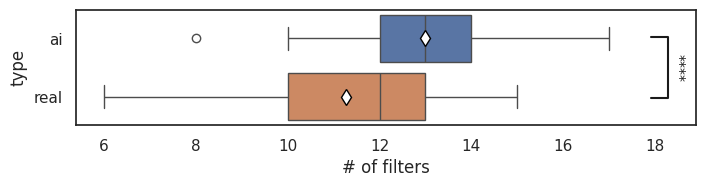

In [505]:
sns.set(rc={'figure.figsize':(8,1.5)})
sns.set_style("white")

ax = sns.boxplot(x="number_of_filters",y="type", hue="type", data=agreement, showmeans=True, meanprops={'marker':'d','markerfacecolor':'white','markeredgecolor':'black','markersize':'8'})
ax.set_xlabel("# of filters")

t_stat, p_value = stats.ttest_ind(agreement[agreement["type"] == "ai"]["number_of_filters"], agreement[agreement["type"] == "real"]["number_of_filters"])

print(p_value)
annotations = [("real", "ai", p_value)]
starbars.draw_annotation(annotations, mode="horizontal")
ax.get_figure().savefig("number_of_filters.pdf", bbox_inches="tight")

d(agreement.sort_values(by=["number_of_filters"]).head(20))
d(agreement.sort_values(by=["number_of_filters"], ascending=False).head(20))